# W2Q1 — Customer Lifetime Journey
**Question:** How long does it take users to move through each funnel stage? Does paid vs organic acquisition affect journey speed?

**Audience:** Product & Marketing Teams  
**Data source:** `ANALYTICS.MARTS.MART_SUBSCRIPTION_FUNNEL`  
**SQL:** `sql/W2Q1_customer_lifetime_journey.sql`

---

> ⚠️ **Data note (DN-002):** Paid subscriptions were not available before Jan 2020.
> Analysis is restricted to users who signed up from Jan 2020 onward.

**Stage timing definitions:**
| Metric | Definition |
|--------|-----------|
| `days_signup_to_trial` | Days from account creation to free trial start |
| `days_trial_to_3m` | Days from trial start to 3m subscription |
| `days_3m_to_12m` | Days from 3m subscription to 12m upgrade |

## Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from src.connection import query

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130})
PALETTE = sns.color_palette('muted', 8)

## Load Data

In [2]:
with open('../sql/W2Q1_customer_lifetime_journey.sql') as f:
    sql = f.read()

df = query(sql)
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head(3)

Rows: 41,817  |  Columns: ['user_id', 'acquisition_type', 'registration_type', 'age', 'funnel_stage', 'has_trial', 'has_3m_subscription', 'has_12m_subscription', 'days_signup_to_trial', 'days_trial_to_3m', 'days_3m_to_12m', 'days_signup_to_3m', 'days_signup_to_12m']


,user_id,acquisition_type,registration_type,age,funnel_stage,has_trial,has_3m_subscription,has_12m_subscription,days_signup_to_trial,days_trial_to_3m,days_3m_to_12m,days_signup_to_3m,days_signup_to_12m
0,100015137,paid,EMAIL,48,2_trial,True,False,False,0.0,NaN,NaN,NaN,NaN
1,100038828,paid,SSO,35,3_monthly,True,True,False,0.0,10.0,NaN,10.0,NaN
2,100061590,paid,EMAIL,32,2_trial,True,False,False,10.0,NaN,NaN,NaN,NaN


## Distribution of Days Between Funnel Stages

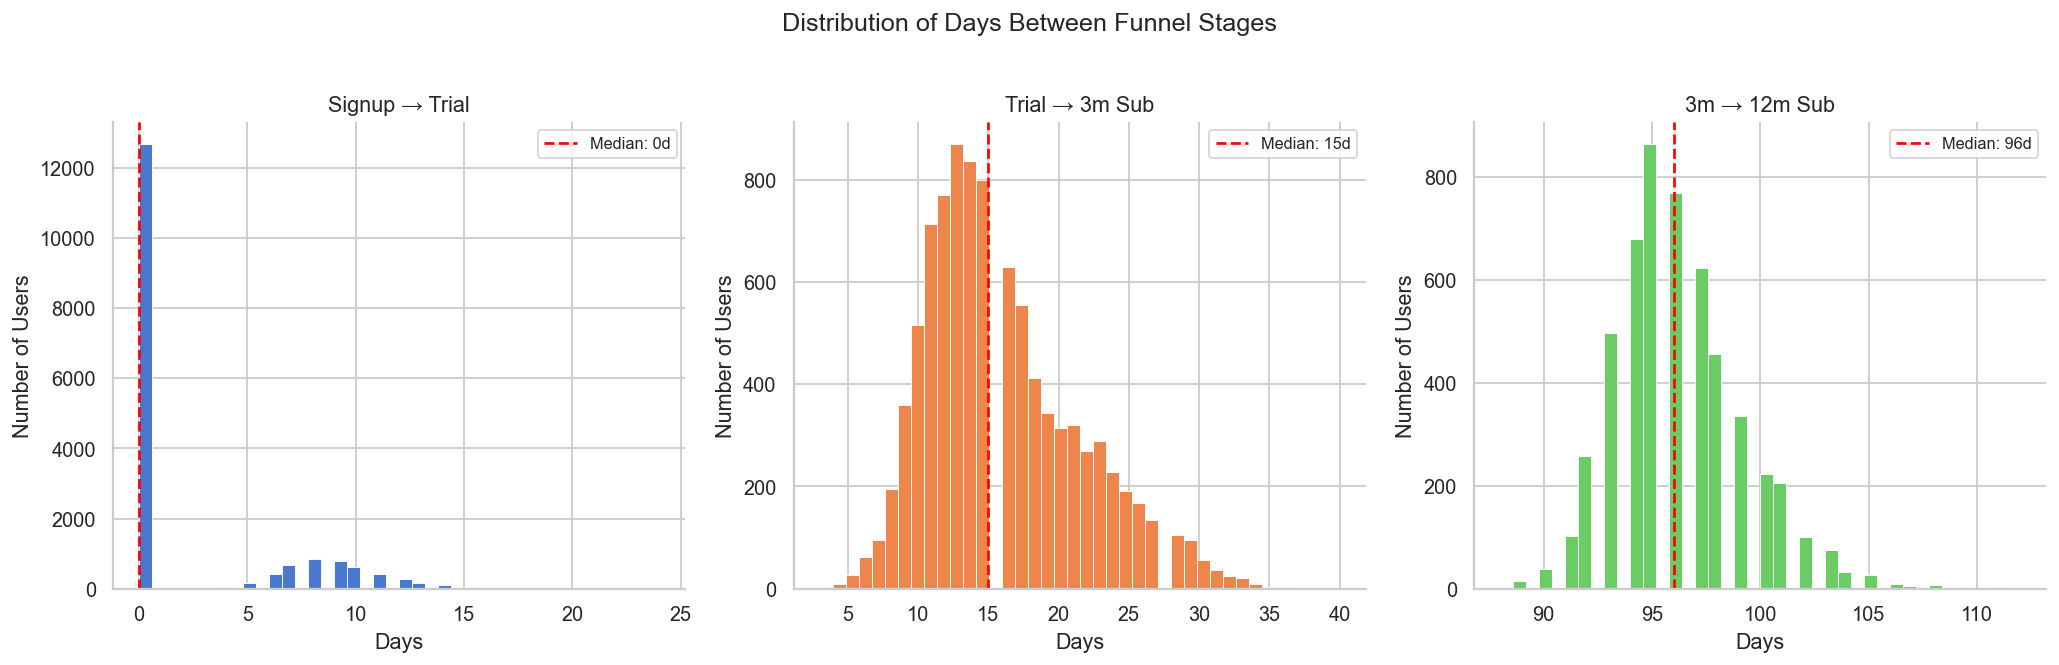

In [3]:
stage_cols = {
    'days_signup_to_trial': 'Signup → Trial',
    'days_trial_to_3m':     'Trial → 3m Sub',
    'days_3m_to_12m':       '3m → 12m Sub',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label), color in zip(axes, stage_cols.items(), PALETTE):
    data = df[col].dropna()
    data = data[data >= 0]  # exclude negative values if any
    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.0f}d')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Days')
    ax.set_ylabel('Number of Users')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Distribution of Days Between Funnel Stages', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/W2Q1_stage_duration_distributions.png', bbox_inches='tight')
plt.show()

## Paid vs Organic — Median Journey Time

In [4]:
summary_rows = []
for col, label in stage_cols.items():
    for acq in ['paid', 'organic']:
        data = df[(df['acquisition_type'] == acq) & df[col].notna()][col]
        data = data[data >= 0]
        summary_rows.append({
            'Stage': label,
            'Acquisition': acq.title(),
            'N': len(data),
            'Median (days)': round(data.median(), 1),
            'P25 (days)': round(data.quantile(0.25), 1),
            'P75 (days)': round(data.quantile(0.75), 1),
            'Mean (days)': round(data.mean(), 1),
        })

summary = pd.DataFrame(summary_rows)
display(summary)

,Stage,Acquisition,N,Median (days),P25 (days),P75 (days),Mean (days)
0,Signup → Trial,Paid,15508,0.0,0.0,6.0,2.4
1,Signup → Trial,Organic,1755,0.0,0.0,5.0,2.3
2,Trial → 3m Sub,Paid,8496,15.0,12.0,19.0,16.0
3,Trial → 3m Sub,Organic,980,15.0,12.0,19.0,15.7
4,3m → 12m Sub,Paid,4786,96.0,94.0,98.0,96.2
5,3m → 12m Sub,Organic,551,96.0,94.0,98.0,96.0


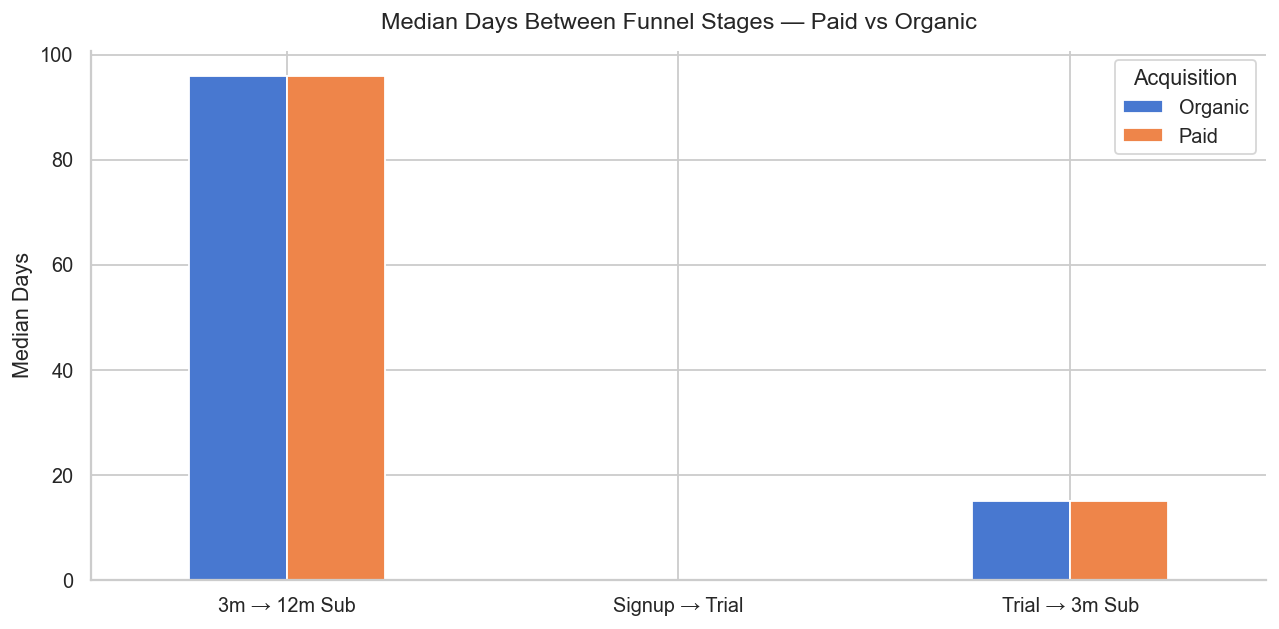

In [5]:
pivot = summary.pivot(index='Stage', columns='Acquisition', values='Median (days)')

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, color=PALETTE[:2], edgecolor='white')
ax.set_title('Median Days Between Funnel Stages — Paid vs Organic', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Median Days')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Acquisition')
sns.despine()
plt.tight_layout()
plt.savefig('../output/W2Q1_paid_vs_organic_journey.png', bbox_inches='tight')
plt.show()

## Funnel Stage Reach Rates

In [6]:
total = len(df)
reach = pd.DataFrame({
    'Stage': ['Has Trial', 'Has 3m Sub', 'Has 12m Sub'],
    'Users': [
        df['has_trial'].sum(),
        df['has_3m_subscription'].sum(),
        df['has_12m_subscription'].sum(),
    ]
})
reach['% of Total'] = (reach['Users'] / total * 100).round(1)
display(reach)

,Stage,Users,% of Total
0,Has Trial,17263,41.3
1,Has 3m Sub,9476,22.7
2,Has 12m Sub,5337,12.8


## Findings

- **Signup → Trial timing (median 0 days, P75 = 6 days):** Most users who ever trial do so on the same day they sign up. 75% of all trial conversions happen within 6 days of signup. The conversion decision is made at or immediately after signup — not after deliberation. This means the signup → trial bottleneck is not a nurturing problem; it is a friction or motivation problem at the moment of signup itself.

- **Trial → 3m timing (median 15 days, IQR 12–19 days):** The 7-day trial ends at day 7; the median conversion to 3m happens at day 15 — roughly 8 days after trial expiry. The IQR is only 7 days wide across ~9,500 users, which is too tight to reflect organic user decision-making. This distribution is consistent with a system-triggered event (trial expiry email, automated payment prompt) firing at a fixed point. Users are not independently deciding when to convert — something is triggering them at a predictable window.

- **3m → 12m timing (median 96 days, IQR 94–98 days):** A 3m subscription lasts 90 days; the median upsell happens 6 days after expiry. The IQR is 4 days — nearly all upsells occur in a 4-day window around day 96. Across 5,300 users, this is almost certainly a renewal campaign or auto-renewal flow firing at a fixed trigger. Users who upgrade are doing so in response to a prompt, not from spontaneous product loyalty.

- **Paid vs organic — no difference at any stage:** Median and IQR are essentially identical across all three stage transitions for paid vs organic users. Acquisition channel has zero bearing on journey speed. The product and its triggered communications are dictating the timing — not where the user came from.

- **Overall funnel reach:** 41.3% of signups ever trial (consistent with W1Q3). Only 22.7% ever pay (3m or 12m), and just 12.8% reach the 12m tier. 77.3% of signups never generate revenue.

- **Recommendation:** The key strategic implication of the tight IQR findings is that **the conversion mechanism is system-driven, not user-driven**. Optimising the trigger — its timing, content, and offer — is likely to have more impact than optimising for user segments. Two immediate follow-ups: (1) Cross-reference with W3Q3 (email timing) to identify whether the triggers are email-based and whether their timing aligns with the day-15 and day-96 conversion peaks. (2) Test shifting the trial-expiry trigger earlier (e.g., day 12 instead of ~day 8 post-trial) to see whether earlier prompting improves conversion without reducing quality.